In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

from _plot_utils import add_aggregate_loss, metric2text

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_18332/4087196625.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("GnBu_r", 7)
/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_18332/4087196625.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("OrRd_r", 7)
/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_18332/4087196625.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = 

56
6.884416372118068 7.316770104960864
-6.280179894316556


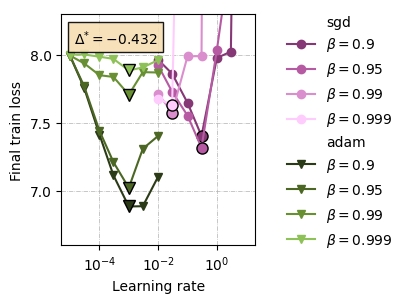

In [ ]:
data = "hg38_char"
path = f"_results/gap_{data}.csv"
metric = "vl_loss"
metric = "tr_loss_ema"
window = 0.01  # percentage of the total steps
ema_alpha = 0.01

bs = 256
betas = [0.9, 0.95, 0.99, 0.999]
beta_n = len(betas)

colors = []
cmap = plt.cm.get_cmap("GnBu_r", 7)
colors.append([cmap(i + 1) for i in range(beta_n)])
cmap = plt.cm.get_cmap("OrRd_r", 7)
colors.append([cmap(i + 1) for i in range(beta_n)])

if "hg38" in data or "zinc" in data:
    colors = []
    cmap = plt.cm.get_cmap("vanimo", 12)
    colors.append([cmap(i + 0) for i in range(beta_n)])
    colors.append([cmap(i + 7) for i in range(beta_n)])
    colors[0].reverse()
if "i1k_imbalanced" in data:
    path = f"_results/gap_i1k_imbalanced_sincos/gap_{data}.csv"

df = pd.read_csv(path)
df = df[df["bs"] == bs]
df = add_aggregate_loss(df, window=window, ema_alpha=ema_alpha)
print(len(df))

if "zinc" in data:
    df = df[df["lr"] != 10]

fig, ax = plt.subplots(1, 1, figsize=(2.5, 3.0), sharey=True)
markers = ["o", "v", "D", "X", "^", "s", "p"]

y_sgd_best, y_adam_best = [], []
for j, beta in enumerate(betas):
    subset = df[df["mom"] == beta]
    sgd = subset[subset["opt"] == "sgd"].sort_values("lr")
    adam = subset[subset["opt"] == "adam"].sort_values("lr")

    ax.plot(
        sgd["lr"],
        sgd[metric],
        color=colors[0][j],
        marker=markers[0],
        label=f"sgd, $\\beta={beta}$",
    )
    ax.plot(
        adam["lr"],
        adam[metric],
        color=colors[1][j],
        marker=markers[1],
        label=f"adam, $\\beta={beta}$",
    )

    # outline the minimum/maximum marker
    if "loss" in metric:
        x_sgd = sgd.loc[sgd[metric].idxmin(), "lr"]
        y_sgd = sgd.loc[sgd[metric].idxmin(), metric]
    elif "acc" in metric:
        x_sgd = sgd.loc[sgd[metric].idxmax(), "lr"]
        y_sgd = sgd.loc[sgd[metric].idxmax(), metric]
    ax.plot(
        x_sgd,
        y_sgd,
        marker=markers[0],
        color=colors[0][j],
        markeredgecolor="black",
        markersize=8,
    )
    if "loss" in metric:
        x_adam = adam.loc[adam[metric].idxmin(), "lr"]
        y_adam = adam.loc[adam[metric].idxmin(), metric]
    elif "acc" in metric:
        x_adam = adam.loc[adam[metric].idxmax(), "lr"]
        y_adam = adam.loc[adam[metric].idxmax(), metric]
    ax.plot(
        x_adam,
        y_adam,
        marker=markers[1],
        color=colors[1][j],
        markeredgecolor="black",
        markersize=8,
    )
    y_adam_best.append(y_adam)
    y_sgd_best.append(y_sgd)

delta_best = min(y_adam_best) - min(y_sgd_best) if "loss" in metric else max(y_adam_best) - max(y_sgd_best)  # fmt: skip
delta_best_percent = (delta_best / min(y_adam_best)) * 100
delta_text = f"$\\mathit{{\\Delta^{{*}}={delta_best:+.3f}}}$"
ax.text(
    0.065,
    0.94 if "loss" in metric else 0.42,
    delta_text,
    transform=ax.transAxes,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(facecolor="wheat", alpha=0.9),
)
print(min(y_adam_best), min(y_sgd_best))
print(delta_best_percent)

data_text = data.replace("imbalanced", "imb")
data_text = data_text.replace("_s4", "")
data_text = data_text.replace("_s6", "")
data_text = data_text.replace("_grit", "")
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
ax.set_xscale("log")
ax.set_xlabel("Learning rate")
ax.grid(True, ls="-.", lw=0.5)

if "c10" in data or "c5m" in data:
    ax.set_ylim(0.6, 1.7)
elif "i1k_imbalanced" in data and metric != "tr_loss_ema":
    ax.set_ylim(0.0, 2.8)
elif "i1k_imbalanced" in data and metric == "tr_loss_ema":
    ax.set_ylim(0.0, 3.8)
elif "i21k" in data:
    ax.set_ylim(5.5, 9.5)
elif "tr_loss" in metric and "hg38_kmer6" in data:
    ax.set_ylim(6.6, 8.3)
elif "vl_loss" in metric and "hg38_kmer6" in data:
    ax.set_ylim(6.2, 8.3)
elif "tr_loss" in metric and "hg38_kmer4" in data:
    ax.set_ylim(4.3, 5.6)
elif "vl_loss" in metric and "hg38_kmer4" in data:
    ax.set_ylim(4.3, 5.6)
elif "tr_loss" in metric and "hg38_char" in data:
    ax.set_ylim(1.05, 1.45)
elif "vl_loss" in metric and "hg38_char" in data:
    ax.set_ylim(1.05, 1.45)
elif "gcnn" in data and bs == 1024:
    ax.set_ylim(4.2, 6.2)
elif "zinc250k" in data:
    ax.set_ylim(0.05, 0.35)

ax.set_ylabel(metric2text[metric])

# reorder labels so that sgd are on top and adam at the bottom
handles, labels = ax.get_legend_handles_labels()
sgd_handles = [h for h, l in zip(handles, labels) if l.startswith("sgd")]
sgd_labels = [l.replace("sgd, ", "") for l in labels if l.startswith("sgd")]
adam_handles = [h for h, l in zip(handles, labels) if l.startswith("adam")]
adam_labels = [l.replace("adam, ", "") for l in labels if l.startswith("adam")]
blank = Line2D([], [], color="none")
fig.legend(
    [blank] + sgd_handles + [blank] + adam_handles,
    ["sgd"] + sgd_labels + ["adam"] + adam_labels,
    loc="upper right",
    bbox_to_anchor=(1.5, 0.92),
    frameon=False,
)
plt.savefig(
    f"_figures/gap_{data}_b{bs}_{metric}.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)